## Question 3: Regression using MLP

AhmadReza Nopoush | sid: 610301194

### Part 1: Preprocessing

first, we load the dataset from google drive.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import pandas as pd

file_path = '/content/drive/MyDrive/DL_HW1/housing.csv'
try:
    dataset = pd.read_csv(file_path)
    print("Data loaded successfully!")
    display(dataset.head())
except FileNotFoundError:
    print(f"Error: The file was not found at {file_path}. Please update the file_path variable with the correct path to your housing.csv file in Google Drive.")
except Exception as e:
    print(f"An error occurred: {e}")

Data loaded successfully!


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


here we can find some information about dataset.

In [3]:
print(dataset.describe())

          longitude      latitude  housing_median_age   total_rooms  \
count  20640.000000  20640.000000        20640.000000  20640.000000   
mean    -119.569704     35.631861           28.639486   2635.763081   
std        2.003532      2.135952           12.585558   2181.615252   
min     -124.350000     32.540000            1.000000      2.000000   
25%     -121.800000     33.930000           18.000000   1447.750000   
50%     -118.490000     34.260000           29.000000   2127.000000   
75%     -118.010000     37.710000           37.000000   3148.000000   
max     -114.310000     41.950000           52.000000  39320.000000   

       total_bedrooms    population    households  median_income  \
count    20433.000000  20640.000000  20640.000000   20640.000000   
mean       537.870553   1425.476744    499.539680       3.870671   
std        421.385070   1132.462122    382.329753       1.899822   
min          1.000000      3.000000      1.000000       0.499900   
25%        296.00000

In [4]:
print(dataset.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB
None


#### handling missing data

to do so, first we need to identify missing values.

In [5]:
# Check How many data has missing values
missing_rows = dataset[dataset.isnull().any(axis=1)]
print(f"Number of rows with missing values: {len(missing_rows)}")
print(f"Percentage of rows with missing values: {len(missing_rows)/len(dataset)*100:.2f}%")

Number of rows with missing values: 207
Percentage of rows with missing values: 1.00%


Now we need to see how many columns of these 207 rows are missing?

In [6]:
# Check for missing values in each column
missing_values = dataset.isnull().sum()
print("Missing values per column:")
print(missing_values)

Missing values per column:
longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64


We find the correlation between `total_bedroom` and other Numercial features(exept target variable).

In [7]:
import numpy as np

numerical_features = dataset.select_dtypes(include=[np.number]).columns.tolist()
numerical_features.remove('median_house_value')  # Exclude target variable
print("Numerical features (excluding target):")
print(numerical_features)

Numerical features (excluding target):
['longitude', 'latitude', 'housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income']


In [8]:
# Create a subset with only numerical features
numerical_housing = dataset[numerical_features]

# Calculate correlation matrix
corr_matrix = numerical_housing.corr()

# Get correlations with total_bedrooms
bedroom_corr = corr_matrix['total_bedrooms'].sort_values(ascending=False)
print("Correlation with total_bedrooms:")
print(bedroom_corr)

# Identify the most correlated feature
print("\nMost Correlated Feature")
print("-" * 40)
most_correlated_feature = bedroom_corr.index[1]  # Skip self-correlation
correlation_value = bedroom_corr.iloc[1]
print(f"Most correlated feature: {most_correlated_feature}")
print(f"Correlation coefficient: {correlation_value:.4f}")

Correlation with total_bedrooms:
total_bedrooms        1.000000
households            0.979728
total_rooms           0.930380
population            0.877747
longitude             0.069608
median_income        -0.007723
latitude             -0.066983
housing_median_age   -0.320451
Name: total_bedrooms, dtype: float64

Most Correlated Feature
----------------------------------------
Most correlated feature: households
Correlation coefficient: 0.9797


As we can see, there is 0.98 correlation between `total_bedroom` and `household`. It means that thes two columns are highly correlated and we can find a regression equation.

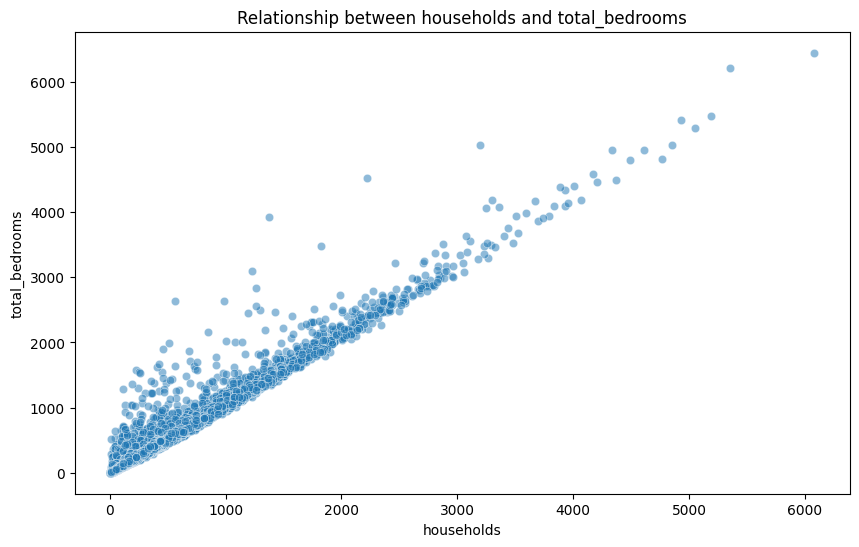

Correlation coefficient: 0.9797


In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

# Explore the relationship between total_bedrooms and the most correlated feature
relationship_data = dataset[[most_correlated_feature, 'total_bedrooms']].dropna()

# Create a scatter plot
plt.figure(figsize=(10, 6))
sns.scatterplot(x=most_correlated_feature, y='total_bedrooms', data=relationship_data, alpha=0.5)
plt.title(f'Relationship between {most_correlated_feature} and total_bedrooms')
plt.xlabel(most_correlated_feature)
plt.ylabel('total_bedrooms')
plt.show()

# Calculate the correlation coefficient using the same subset
corr_coef = np.corrcoef(
    relationship_data[most_correlated_feature],
    relationship_data['total_bedrooms']
)[0, 1]
print(f"Correlation coefficient: {corr_coef:.4f}")

Now we build a linear regression model for imputation

Regression equation: total_bedrooms = 1.0799 * households + -1.4649



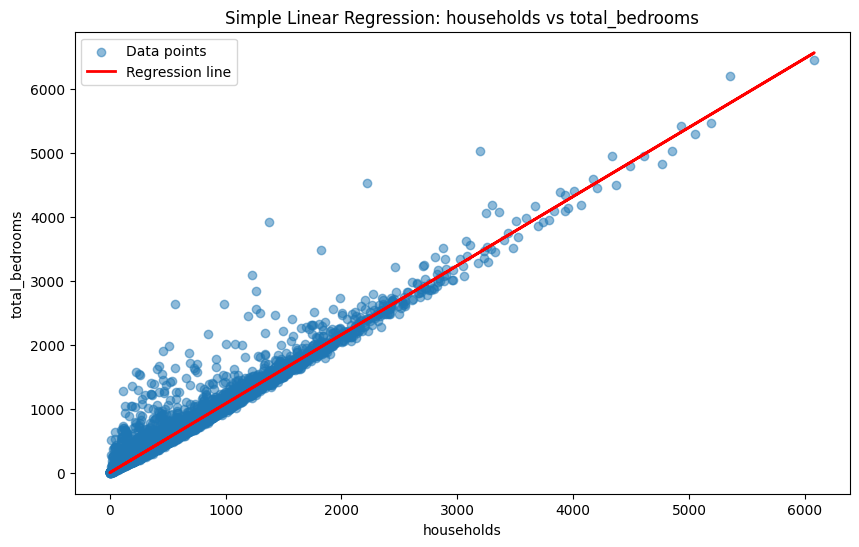

In [10]:
# Extract x and y from the relationship data
x = relationship_data[most_correlated_feature].values
y = relationship_data['total_bedrooms'].values

# Calculate slope and intercept
n = len(x)
x_mean = np.mean(x)
y_mean = np.mean(y)

# Calculate slope (b1)
numerator = np.sum((x - x_mean) * (y - y_mean))
denominator = np.sum((x - x_mean) ** 2)
slope = numerator / denominator

# Calculate intercept (b0)
intercept = y_mean - slope * x_mean
print(f"Regression equation: total_bedrooms = {slope:.4f} * {most_correlated_feature} + {intercept:.4f}\n")

# Visualize the regression line
plt.figure(figsize=(10, 6))
plt.scatter(x, y, alpha=0.5, label='Data points')
plt.plot(x, slope * x + intercept, color='red', linewidth=2, label='Regression line')
plt.title(f'Simple Linear Regression: {most_correlated_feature} vs total_bedrooms')
plt.xlabel(most_correlated_feature)
plt.ylabel('total_bedrooms')
plt.legend()
plt.show()

Now we can impute missing values using the regression equation. note that Because there is a high correlation between these two columns, using the regression equation gives us a good approximation for estimating the missing value.

In [11]:
# Identify rows with missing total_bedrooms
missing_mask = dataset['total_bedrooms'].isnull()

# Get the values of the most correlated feature for these rows
x_missing = dataset.loc[missing_mask, most_correlated_feature].values

# Predict the missing values using the regression equation
predicted_bedrooms = slope * x_missing + intercept

# Fill in the missing values
dataset_imputed = dataset.copy()
dataset_imputed.loc[missing_mask, 'total_bedrooms'] = predicted_bedrooms

# Verify that missing values have been filled
print("Missing values after imputation:")
print(dataset_imputed.isnull().sum())

Missing values after imputation:
longitude             0
latitude              0
housing_median_age    0
total_rooms           0
total_bedrooms        0
population            0
households            0
median_income         0
median_house_value    0
ocean_proximity       0
dtype: int64


Now, to see the difference we compare distributions before and after imputation. also we can use mean imputation and compare this two strategy.

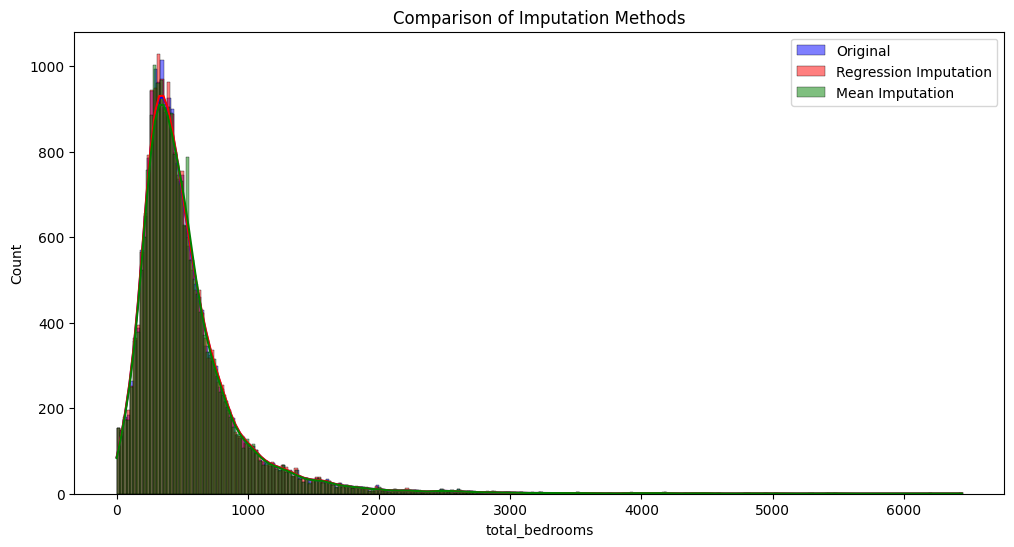


Difference in statistics from original (non-missing) data:
Regression Imputation:
  Mean difference: 0.1147
  Std difference: -0.0525

Mean Imputation:
  Mean difference: -0.0000
  Std difference: -2.1185


In [12]:
# Apply median imputation
housing_mean = dataset.copy()
mean_value = housing_mean['total_bedrooms'].mean()
# Fix: Use direct assignment instead of inplace=True
housing_mean['total_bedrooms'] = housing_mean['total_bedrooms'].fillna(mean_value)

# Compare distributions
plt.figure(figsize=(12, 6))
sns.histplot(dataset['total_bedrooms'].dropna(), color='blue', label='Original', kde=True)
sns.histplot(dataset_imputed['total_bedrooms'], color='red', label='Regression Imputation', kde=True)
sns.histplot(housing_mean['total_bedrooms'], color='green', label='Mean Imputation', kde=True)
plt.title('Comparison of Imputation Methods')
plt.xlabel('total_bedrooms')
plt.legend()
plt.show()

# Calculate the difference in mean and standard deviation
print("\nDifference in statistics from original (non-missing) data:")
print("Regression Imputation:")
print(f"  Mean difference: {dataset_imputed['total_bedrooms'].mean() - dataset['total_bedrooms'].dropna().mean():.4f}")
print(f"  Std difference: {dataset_imputed['total_bedrooms'].std() - dataset['total_bedrooms'].dropna().std():.4f}")
print("\nMean Imputation:")
print(f"  Mean difference: {housing_mean['total_bedrooms'].mean() - dataset['total_bedrooms'].dropna().mean():.4f}")
print(f"  Std difference: {housing_mean['total_bedrooms'].std() - dataset['total_bedrooms'].dropna().std():.4f}")

#### handling outliers

first, we plot distribution and boxplot of the target variable.

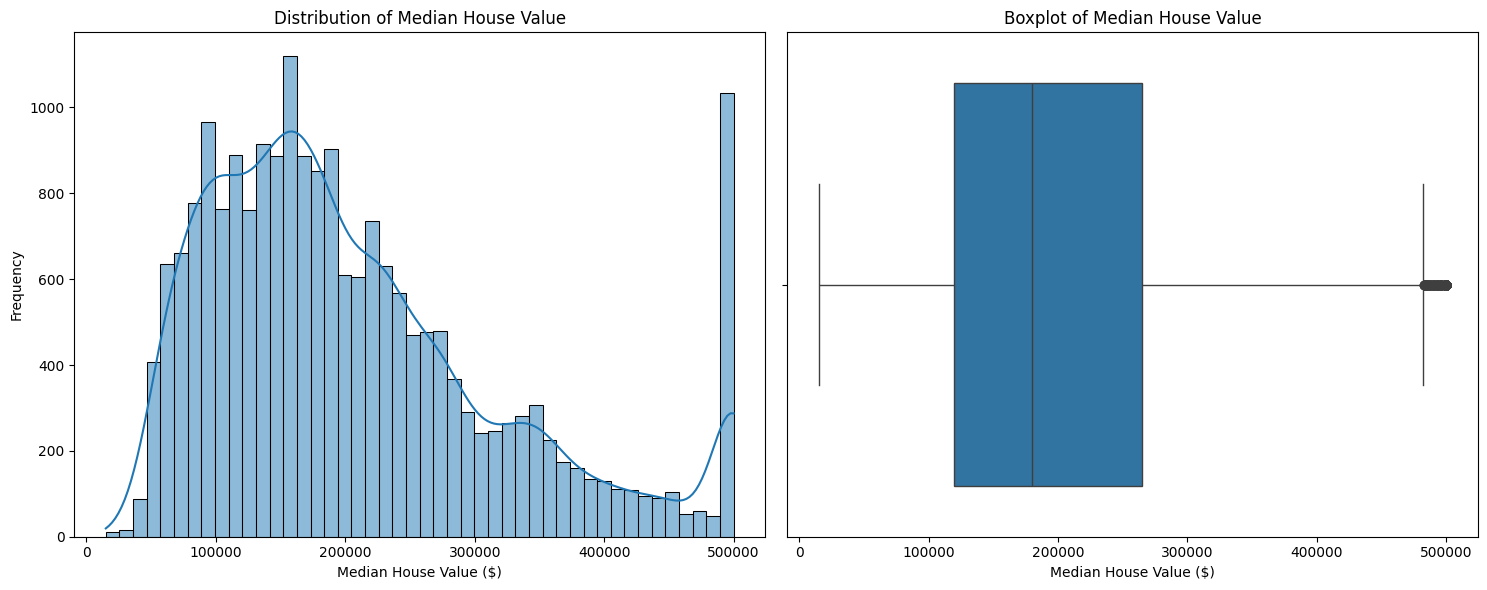

In [13]:
plt.figure(figsize=(15, 6))

# Histogram
plt.subplot(1, 2, 1)
sns.histplot(dataset_imputed['median_house_value'], kde=True)
plt.title('Distribution of Median House Value')
plt.xlabel('Median House Value ($)')
plt.ylabel('Frequency')

# Boxplot
plt.subplot(1, 2, 2)
sns.boxplot(x=dataset_imputed['median_house_value'])
plt.title('Boxplot of Median House Value')
plt.xlabel('Median House Value ($)')

plt.tight_layout()
plt.show()

as we can see from the distirbution, there might be outliers in upperbound.

Now we use Outlier Detection using Median Test (IQR Method).

In [14]:
# Calculate Q1, Q3, and IQR
Q1 = dataset_imputed['median_house_value'].quantile(0.25)
Q3 = dataset_imputed['median_house_value'].quantile(0.75)
IQR = Q3 - Q1

# Define outlier bounds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Identify outliers
median_outliers = dataset_imputed[
    (dataset_imputed['median_house_value'] < lower_bound) |
    (dataset_imputed['median_house_value'] > upper_bound)
]

print(f"Q1: ${Q1:.2f}")
print(f"Q3: ${Q3:.2f}")
print(f"IQR: ${IQR:.2f}")
print(f"Lower bound: ${lower_bound:.2f}")
print(f"Upper bound: ${upper_bound:.2f}")
print(f"Number of outliers detected: {len(median_outliers)}")
print(f"Percentage of outliers: {len(median_outliers) / len(dataset_imputed) * 100:.2f}%")

Q1: $119600.00
Q3: $264725.00
IQR: $145125.00
Lower bound: $-98087.50
Upper bound: $482412.50
Number of outliers detected: 1071
Percentage of outliers: 5.19%


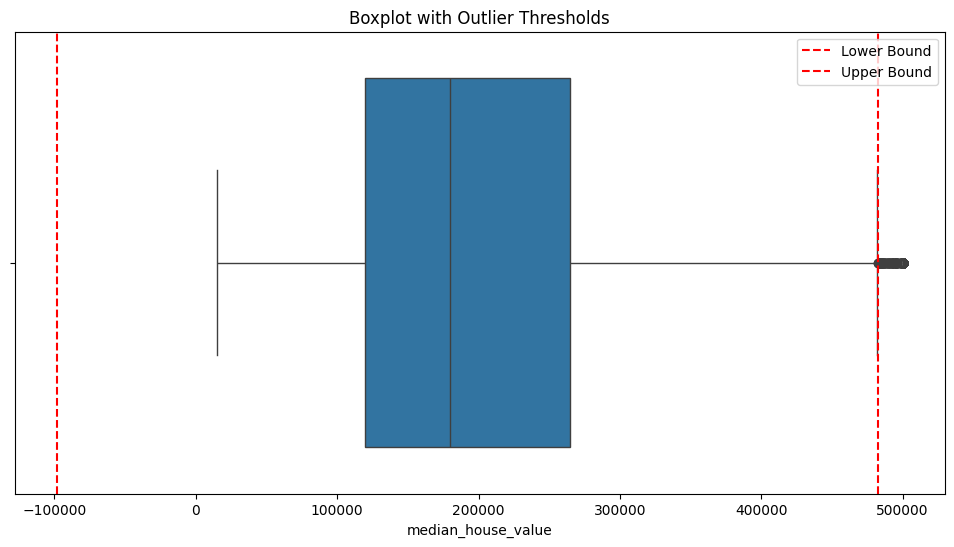

In [15]:
# Visualize outliers
plt.figure(figsize=(12, 6))
sns.boxplot(x=dataset_imputed['median_house_value'])
plt.title('Boxplot with Outlier Thresholds')
plt.axvline(x=lower_bound, color='red', linestyle='--', label='Lower Bound')
plt.axvline(x=upper_bound, color='red', linestyle='--', label='Upper Bound')
plt.legend()
plt.show()

So, base on the test, 5% of our data have outliered targetvariable.

 Now we are going to remove outliers.

In [16]:
dataset_clean = dataset_imputed.copy()
dataset_clean = dataset_clean[
    (dataset_clean['median_house_value'] >= lower_bound) &
    (dataset_clean['median_house_value'] <= upper_bound)
]

print(f"Original dataset size: {len(dataset_imputed)}")
print(f"Dataset size after removing outliers: {len(dataset_clean)}")
print(f"Number of outliers removed: {len(dataset_imputed) - len(dataset_clean)}")
print(f"Percentage of data removed: {(len(dataset_imputed) - len(dataset_clean)) / len(dataset_imputed) * 100:.2f}%")


Original dataset size: 20640
Dataset size after removing outliers: 19569
Number of outliers removed: 1071
Percentage of data removed: 5.19%


Now, we Visualize the cleaned data

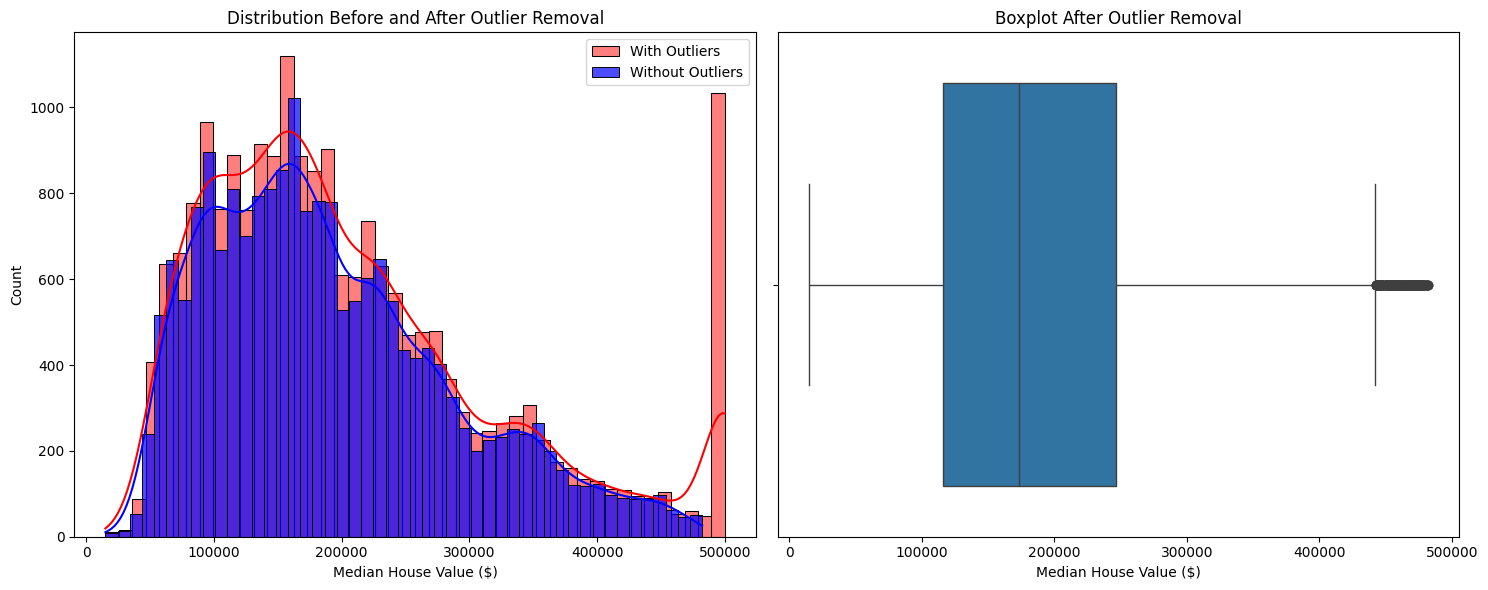

In [17]:
from scipy import stats

plt.figure(figsize=(15, 6))

# Before and after comparison
plt.subplot(1, 2, 1)
sns.histplot(dataset_imputed['median_house_value'], kde=True, color='red', alpha=0.5, label='With Outliers')
sns.histplot(dataset_clean['median_house_value'], kde=True, color='blue', alpha=0.7, label='Without Outliers')
plt.title('Distribution Before and After Outlier Removal')
plt.xlabel('Median House Value ($)')
plt.legend()

plt.subplot(1, 2, 2)
sns.boxplot(x=dataset_clean['median_house_value'])
plt.title('Boxplot After Outlier Removal')
plt.xlabel('Median House Value ($)')

plt.tight_layout()
plt.show()

Now, we Compare statistics before and after outlier removal

In [18]:
# Calculate percentage change
mean_change = (dataset_clean['median_house_value'].mean() - dataset_imputed['median_house_value'].mean()) / dataset_imputed['median_house_value'].mean() * 100
std_change = (dataset_clean['median_house_value'].std() - dataset_imputed['median_house_value'].std()) / dataset_imputed['median_house_value'].std() * 100

print(f"\nMean change: {mean_change:.2f}%")
print(f"Standard deviation change: {std_change:.2f}%")


Mean change: -7.74%
Standard deviation change: -17.29%


#### one-hot

first, we should identify all categorical features

In [19]:
# Get data types of all columns
print("Data types of all columns:")
print(dataset_clean.dtypes)

# Identify categorical features (non-numeric columns)
categorical_features = dataset_clean.select_dtypes(include=['object', 'category']).columns.tolist()
print(f"\nCategorical features found: {categorical_features}")

Data types of all columns:
longitude             float64
latitude              float64
housing_median_age    float64
total_rooms           float64
total_bedrooms        float64
population            float64
households            float64
median_income         float64
median_house_value    float64
ocean_proximity        object
dtype: object

Categorical features found: ['ocean_proximity']


As we can see, only `ocean_proximity` is categorical.


Value counts for 'ocean_proximity':
ocean_proximity
<1H OCEAN     8552
INLAND        6519
NEAR OCEAN    2419
NEAR BAY      2074
ISLAND           5
Name: count, dtype: int64


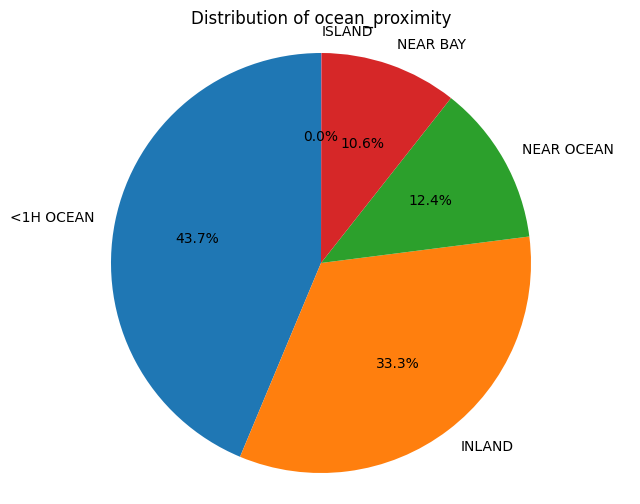

In [20]:
# Count the occurrences of each category
print("\nValue counts for 'ocean_proximity':")
ocean_counts = dataset_clean['ocean_proximity'].value_counts()
print(ocean_counts)

# Visualize the distribution
plt.figure(figsize=(8, 6))
plt.pie(ocean_counts, labels=ocean_counts.index, autopct='%1.1f%%', startangle=90)
plt.title(f'Distribution of ocean_proximity')
plt.axis('equal')
plt.show()

since this categorical features are nominal (and not ordinal) we perform one-hot encoding.

In [21]:
# Create one-hot encoded columns
one_hot = pd.get_dummies(dataset_clean['ocean_proximity'], prefix='ocean', dtype=int)

# Join the one-hot encoded columns with the original dataframe
housing_encoded = pd.concat([dataset_clean, one_hot], axis=1)

# Check the new columns
print("\nNew columns added:")
new_columns = one_hot.columns.tolist()
print(new_columns)

# Drop the original ocean_proximity column
housing_encoded = housing_encoded.drop('ocean_proximity', axis=1)

# Verify the column has been removed
print("Columns after removing 'ocean_proximity':")
print(housing_encoded.columns.tolist())

# Display the shape of the dataset
print(f"\nDataset shape: {housing_encoded.shape}")
print(f"Number of features: {housing_encoded.shape[1] - 1} (excluding target)")
print(f"Number of samples: {housing_encoded.shape[0]}")


New columns added:
['ocean_<1H OCEAN', 'ocean_INLAND', 'ocean_ISLAND', 'ocean_NEAR BAY', 'ocean_NEAR OCEAN']
Columns after removing 'ocean_proximity':
['longitude', 'latitude', 'housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income', 'median_house_value', 'ocean_<1H OCEAN', 'ocean_INLAND', 'ocean_ISLAND', 'ocean_NEAR BAY', 'ocean_NEAR OCEAN']

Dataset shape: (19569, 14)
Number of features: 13 (excluding target)
Number of samples: 19569


Now we finished the preprocessing part. our preprocessed data is available in `DS`

In [22]:
DS = housing_encoded.copy()

### Part 2: Model Implementation

importing libraries

In [23]:
import torch
if (torch.cuda.is_available()):
    DEVICE = 'cuda'
else:
    DEVICE = 'cpu'
print(DEVICE)

cpu


In [24]:
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import random_split, Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from torch.utils.data import TensorDataset
import torch.nn as nn
import torch.optim as optim
import time

#### Splitting and Normalization

first thing we should do is seperating target from features.

In [25]:
# Separate features and target
X = DS.drop('median_house_value', axis=1).values
y = DS['median_house_value'].values.reshape(-1, 1)

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")

Features shape: (19569, 13)
Target shape: (19569, 1)


Now we split dataset into train, validation and test sets.

In [26]:
# First split: 80% train, 20% temp
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.2)

# Second split: 50% validation, 50% test (of the 20% temp)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5)

print(f"Training set size: {X_train.shape[0]} samples")
print(f"Validation set size: {X_val.shape[0]} samples")
print(f"Test set size: {X_test.shape[0]} samples")

Training set size: 15655 samples
Validation set size: 1957 samples
Test set size: 1957 samples


Now we use `MinMaxScaler` to Normalize our data into [0,1]

In [27]:
# Initialize scaler
scaler = MinMaxScaler()

# Fit on training data and transform all sets
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

# Convert to PyTorch tensors
X_train_tensor = torch.FloatTensor(X_train)
y_train_tensor = torch.FloatTensor(y_train)
X_val_tensor = torch.FloatTensor(X_val)
y_val_tensor = torch.FloatTensor(y_val)
X_test_tensor = torch.FloatTensor(X_test)
y_test_tensor = torch.FloatTensor(y_test)

# Create DataLoader
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)

val_dataset = TensorDataset(X_val_tensor, y_val_tensor)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=True)

test_dataset = TensorDataset(X_test_tensor, y_test_tensor)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=True)

#### Model Architecture

| Layer  | Input      | Output | Activation |
| ------ | ---------- | ------ | ---------- |
| Linear | input_size | 8      | ReLU       |
| Linear | 8          | 1      | —          |

Based on the given neural network architecture table, the implementation is:

In [28]:
class FullyConnectedNN(nn.Module):
    def __init__(self, input_size):
        super(FullyConnectedNN, self).__init__()
        self.layer1 = nn.Linear(input_size, 8)
        self.layer2 = nn.Linear(8, 1)

    def forward(self, x):
        out = self.layer1(x)
        out = torch.nn.functional.relu(out)
        out = self.layer2(out)
        return out

#### Training Functions

In [29]:
def fit(model, train_loader, optimizer, criterion):
    model.train()   # Training mode
    train_running_loss = 0.0
    counter = 0

    for input, target in train_loader:
        counter += 1
        outputs = model(input)   # Calculate outputs
        loss = criterion(outputs, target)     # Calculate Loss

        optimizer.zero_grad()   # Reset gradients
        loss.backward()   # Backpropagate the loss
        optimizer.step()   # Update the weights

        train_running_loss += loss.item()

    train_loss = train_running_loss / counter  # Average epoch loss
    return train_loss

In [30]:
# Function for evaluating the validation data (adapted for regression)
def validation(model, data_loader, criterion):
    model.eval()    # Evaluation mode (do not allow weight updates)
    val_running_loss = 0.0
    counter = 0

    with torch.no_grad():  # No need to calculate gradients during validation
        for input, target in data_loader:
            counter += 1
            outputs = model(input)
            loss = criterion(outputs, target)
            val_running_loss += loss.item()

    val_loss = val_running_loss / counter
    return val_loss

In [31]:
# The main method for training the model through epochs
def train(model, hparams, train_loader, val_loader,test_loader):
    input_size = X_train.shape[1]
    optimizer = optim.Adam(model.parameters(), lr=hparams['lr'])
    criterion = nn.MSELoss()  # Mean Squared Error Loss for regression

    train_loss = []
    val_loss = []
    test_loss = []

    start = time.time()

    # Loop over epochs
    for epoch in range(hparams['epochs']):
        print(f"Epoch {epoch+1} of {hparams['epochs']}")
        train_epoch_loss = fit(model, train_loader, optimizer, criterion)
        val_epoch_loss = validation(model, val_loader, criterion)
        test_epoch_loss = validation(model, test_loader, criterion)


        train_loss.append(train_epoch_loss)
        val_loss.append(val_epoch_loss)
        test_loss.append(test_epoch_loss)
        print(f"Train Loss: {train_epoch_loss:.4f}, Val Loss: {val_epoch_loss:.4f}, Test Loss: {test_epoch_loss:.4f}")

    end = time.time()
    print(f"Training time: {(end-start)/60:.3f} minutes")

    return model, train_loss, val_loss, test_loss

### Part 3: Training the Simple MLP

In [32]:
# Hyperparameters dict
hparams = {'batch_size': 64, 'lr': 0.1, 'epochs': 60}

model = FullyConnectedNN(input_size=X_train.shape[1])
model.to(DEVICE)

from torchsummary import summary
summary(model,input_size=(1,X_train.shape[1]), batch_size=hparams['batch_size'])  ## Model summary

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Linear-1                 [64, 1, 8]             112
            Linear-2                 [64, 1, 1]               9
Total params: 121
Trainable params: 121
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.00
Forward/backward pass size (MB): 0.00
Params size (MB): 0.00
Estimated Total Size (MB): 0.01
----------------------------------------------------------------


now we train the defined model on our preprocessed data.

In [33]:
model, train_loss, val_loss, test_loss = train(model, hparams, train_loader, val_loader, test_loader)

Epoch 1 of 60
Train Loss: 42595552310.3347, Val Loss: 35108845898.3226, Test Loss: 36293902336.0000
Epoch 2 of 60
Train Loss: 26605866289.1102, Val Loss: 16991680512.0000, Test Loss: 17729832695.7419
Epoch 3 of 60
Train Loss: 12391943422.9551, Val Loss: 8755408417.0323, Test Loss: 9117994149.1613
Epoch 4 of 60
Train Loss: 7979501916.9959, Val Loss: 7169595804.9032, Test Loss: 7374353639.2258
Epoch 5 of 60
Train Loss: 6995817128.2286, Val Loss: 6626653431.7419, Test Loss: 6835734404.1290
Epoch 6 of 60
Train Loss: 6583080035.2653, Val Loss: 6358626188.3871, Test Loss: 6499413611.3548
Epoch 7 of 60
Train Loss: 6331938310.2694, Val Loss: 6144435637.6774, Test Loss: 6316732721.5484
Epoch 8 of 60
Train Loss: 6163688530.5469, Val Loss: 6029038509.4194, Test Loss: 6122394838.7097
Epoch 9 of 60
Train Loss: 6034572751.9347, Val Loss: 5931681230.4516, Test Loss: 5984065387.3548
Epoch 10 of 60
Train Loss: 5929006062.2367, Val Loss: 5775290103.7419, Test Loss: 5891088631.7419
Epoch 11 of 60
Train L

first thing to do is Plot the loss curve

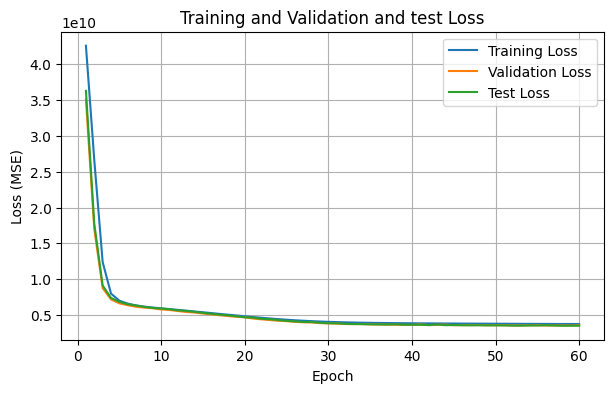

In [34]:
plt.figure(figsize=(7, 4))
plt.plot(range(1, hparams['epochs'] + 1), train_loss, label='Training Loss')
plt.plot(range(1, hparams['epochs'] + 1), val_loss, label='Validation Loss')
plt.plot(range(1, hparams['epochs'] + 1), test_loss, label='Test Loss')
plt.title('Training and Validation and test Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.grid(True)
plt.show()

#### Evaluation Metrics

In [35]:
def Calculate_Metrics(y_true, y_pred):
    if isinstance(y_true, torch.Tensor): y_true = y_true.detach().numpy()
    if isinstance(y_pred, torch.Tensor): y_pred = y_pred.detach().numpy()
    mse = np.mean((y_true - y_pred) ** 2)
    rmse = np.sqrt(mse)
    mae = np.mean(np.abs(y_true - y_pred))
    r2 = 1 - np.sum((y_true - y_pred)**2) / np.sum((y_true - np.mean(y_true))**2)
    return mse, rmse, mae, r2


In [36]:
def evaluate_model(model, data_loader, metric_calculator):
    model.eval()
    predictions = []
    targets = []

    with torch.no_grad():
        for inputs, batch_targets in data_loader:
            outputs = model(inputs)
            predictions.append(outputs)
            targets.append(batch_targets)

    predictions = torch.cat(predictions)
    targets = torch.cat(targets)

    mse, rmse, mae, r2 = metric_calculator(targets, predictions)

    return mse, rmse, mae, r2, predictions, targets

train_mse, train_rmse, train_mae, train_r2, train_predictions, train_targets = evaluate_model(
    model, train_loader, Calculate_Metrics
)
print(f"Train MSE: {train_mse:.4f}")
print(f"Train RMSE: {train_rmse:.4f}")
print(f"Train MAE: {train_mae:.4f}")
print(f"Train R²: {train_r2:.4f}")

test_mse, test_rmse, test_mae, test_r2, test_predictions, test_targets = evaluate_model(
    model, test_loader, Calculate_Metrics
)
print(f"\nTest MSE: {test_mse:.4f}")
print(f"Test RMSE: {test_rmse:.4f}")
print(f"Test MAE: {test_mae:.4f}")
print(f"Test R²: {test_r2:.4f}")

val_mse, val_rmse, val_mae, val_r2, val_predictions, val_targets = evaluate_model(
    model, val_loader, Calculate_Metrics
)
print(f"\nVal MSE: {val_mse:.4f}")
print(f"Val RMSE: {val_rmse:.4f}")
print(f"Val MAE: {val_mae:.4f}")
print(f"Val R²: {val_r2:.4f}")

Train MSE: 3729259776.0000
Train RMSE: 61067.6641
Train MAE: 45089.0469
Train R²: 0.5912

Test MSE: 3493641472.0000
Test RMSE: 59107.0352
Test MAE: 44065.1680
Test R²: 0.6185

Val MSE: 3523648000.0000
Val RMSE: 59360.3242
Val MAE: 43760.2812
Val R²: 0.6055


for last part, we visualize predictions vs actual values.

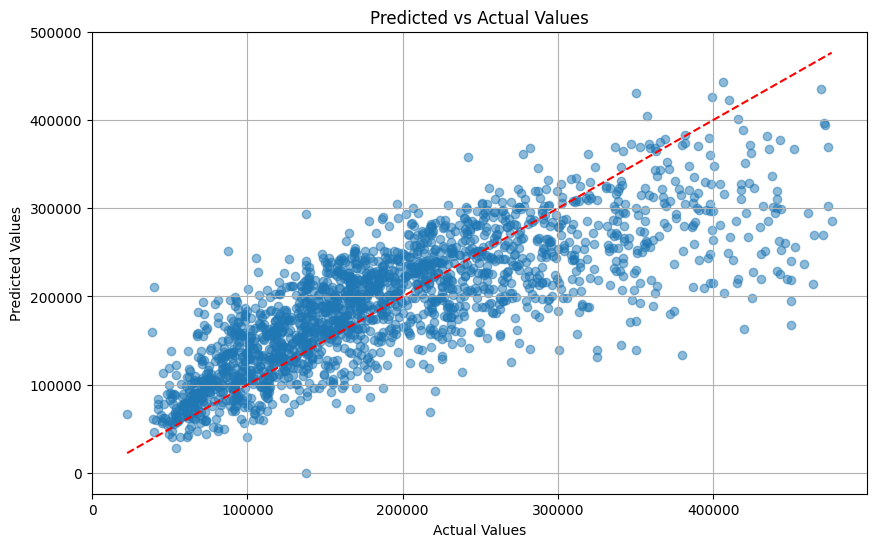

In [37]:
plt.figure(figsize=(10, 6))
plt.scatter(test_targets.numpy(), test_predictions.numpy(), alpha=0.5)
plt.plot([test_targets.min(), test_targets.max()], [test_targets.min(), test_targets.max()], 'r--')
plt.title('Predicted vs Actual Values')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.grid(True)
plt.show()

### Part 4: Implemnting more complicated MLP

here, in order to reach a better estimation of target variable, we define and implement a new model with higher complexity.

**Model Hyperparameters** is as is below

In [38]:
# Hyperparameters dict
HyperParam = {'batch_size': 32,
           'lr': 0.098,
           'epochs': 60}

In [39]:
# Create New DataLoader
C_train_loader = DataLoader(train_dataset, batch_size = HyperParam['batch_size'], shuffle=True)

C_val_loader = DataLoader(val_dataset, batch_size = HyperParam['batch_size'], shuffle=True)

C_test_loader = DataLoader(test_dataset, batch_size = HyperParam['batch_size'], shuffle=True)

**Network Architecture**

In [40]:
class ComplicateFCNN(nn.Module):
    def __init__(self, input_size):
        super(ComplicateFCNN, self).__init__()
        self.layer1 = nn.Linear(input_size, 32)
        self.layer2 = nn.Linear(32, 64)
        self.layer3 = nn.Linear(64, 16)
        self.layer4 = nn.Linear(16, 1)

    def forward(self, x):
        out = self.layer1(x)
        out = torch.nn.functional.silu(out)
        out = self.layer2(out)
        out = torch.nn.functional.silu(out)
        out = self.layer3(out)
        out = torch.nn.functional.silu(out)
        out = self.layer4(out)
        return out

In [41]:
C_model = ComplicateFCNN(input_size=X_train.shape[1])
C_model.to(DEVICE)

summary(C_model,input_size=(1,X_train.shape[1]), batch_size=HyperParam['batch_size'])  ## Model summary

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Linear-1                [32, 1, 32]             448
            Linear-2                [32, 1, 64]           2,112
            Linear-3                [32, 1, 16]           1,040
            Linear-4                 [32, 1, 1]              17
Total params: 3,617
Trainable params: 3,617
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.00
Forward/backward pass size (MB): 0.03
Params size (MB): 0.01
Estimated Total Size (MB): 0.04
----------------------------------------------------------------


**Model Training**

In [42]:
C_model, C_train_loss, C_val_loss, C_test_loss = train(C_model, HyperParam, C_train_loader, C_val_loader, C_test_loader)

Epoch 1 of 60
Train Loss: 6170674767.8041, Val Loss: 3521933501.9355, Test Loss: 3558236807.2258
Epoch 2 of 60
Train Loss: 3639638401.0449, Val Loss: 3312492946.5806, Test Loss: 3363305913.8065
Epoch 3 of 60
Train Loss: 3493590145.3061, Val Loss: 3120265306.8387, Test Loss: 2927142140.3871
Epoch 4 of 60
Train Loss: 3354914089.4041, Val Loss: 3103895843.0968, Test Loss: 2992529333.6774
Epoch 5 of 60
Train Loss: 3250703706.6449, Val Loss: 3024259090.5806, Test Loss: 3017892086.7097
Epoch 6 of 60
Train Loss: 3228938212.7020, Val Loss: 3266918796.9032, Test Loss: 2977710765.4194
Epoch 7 of 60
Train Loss: 3198511240.2286, Val Loss: 2894292432.5161, Test Loss: 2680611069.4194
Epoch 8 of 60
Train Loss: 3051704251.4286, Val Loss: 2874058289.5484, Test Loss: 2660775286.4516
Epoch 9 of 60
Train Loss: 3018373050.3837, Val Loss: 2884395169.0323, Test Loss: 2636790624.5161
Epoch 10 of 60
Train Loss: 2973643230.5633, Val Loss: 2929600413.9355, Test Loss: 2733152659.6129
Epoch 11 of 60
Train Loss: 29

here we can see the training loss and validation loss during epochs

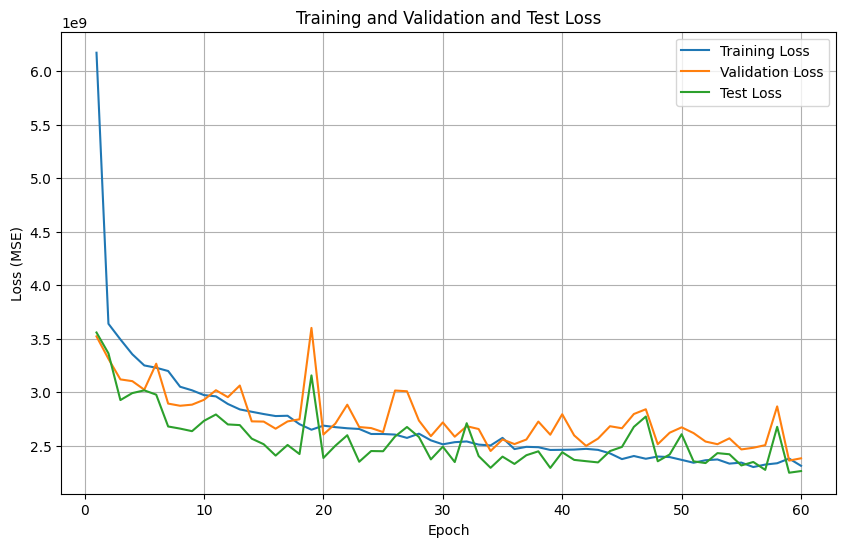

In [43]:
plt.figure(figsize=(10, 6))
plt.plot(range(1, HyperParam['epochs'] + 1), C_train_loss, label='Training Loss')
plt.plot(range(1, HyperParam['epochs'] + 1), C_val_loss, label='Validation Loss')
plt.plot(range(1, HyperParam['epochs'] + 1), C_test_loss, label='Test Loss')
plt.title('Training and Validation and Test Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.grid(True)
plt.show()

Evaluation metrics on test data

In [44]:
# Evaluate complex model on training set
C_train_mse, C_train_rmse, C_train_mae, C_train_r2, C_train_predictions, C_train_targets = evaluate_model(
    C_model, C_train_loader, Calculate_Metrics
)
print(f"Train MSE: {C_train_mse:.4f}")
print(f"Train RMSE: {C_train_rmse:.4f}")
print(f"Train MAE: {C_train_mae:.4f}")
print(f"Train R²: {C_train_r2:.4f}")

# Evaluate complex model on test set
C_test_mse, C_test_rmse, C_test_mae, C_test_r2, C_test_predictions, C_test_targets = evaluate_model(
    C_model, C_test_loader, Calculate_Metrics
)
print(f"\nTest MSE: {C_test_mse:.4f}")
print(f"Test RMSE: {C_test_rmse:.4f}")
print(f"Test MAE: {C_test_mae:.4f}")
print(f"Test R²: {C_test_r2:.4f}")

# Evaluate complex model on validation set
C_val_mse, C_val_rmse, C_val_mae, C_val_r2, C_val_predictions, C_val_targets = evaluate_model(
    C_model, C_val_loader, Calculate_Metrics
)
print(f"\nVal MSE: {C_val_mse:.4f}")
print(f"Val RMSE: {C_val_rmse:.4f}")
print(f"Val MAE: {C_val_mae:.4f}")
print(f"Val R²: {C_val_r2:.4f}")

Train MSE: 2201408512.0000
Train RMSE: 46919.1719
Train MAE: 32481.4824
Train R²: 0.7587

Test MSE: 2289352704.0000
Test RMSE: 47847.1797
Test MAE: 32991.2773
Test R²: 0.7500

Val MSE: 2409209088.0000
Val RMSE: 49083.6953
Val MAE: 33414.4766
Val R²: 0.7303


Predicted vs Actual Values Graph for the model

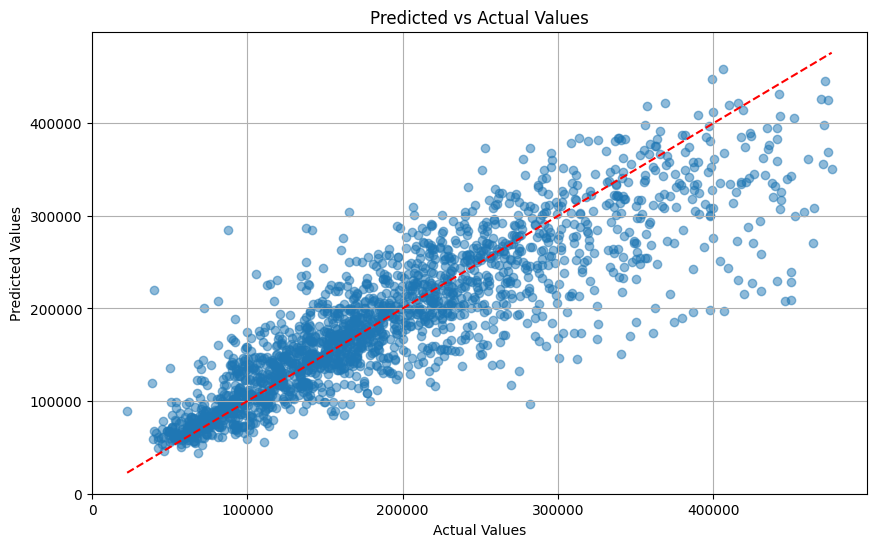

In [45]:
plt.figure(figsize=(10, 6))
plt.scatter(C_test_targets.numpy(), C_test_predictions.numpy(), alpha=0.5)
plt.plot([C_test_targets.min(), C_test_targets.max()], [C_test_targets.min(), C_test_targets.max()], 'r--')
plt.title('Predicted vs Actual Values')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.grid(True)
plt.show()

### Part 5: Conclusions

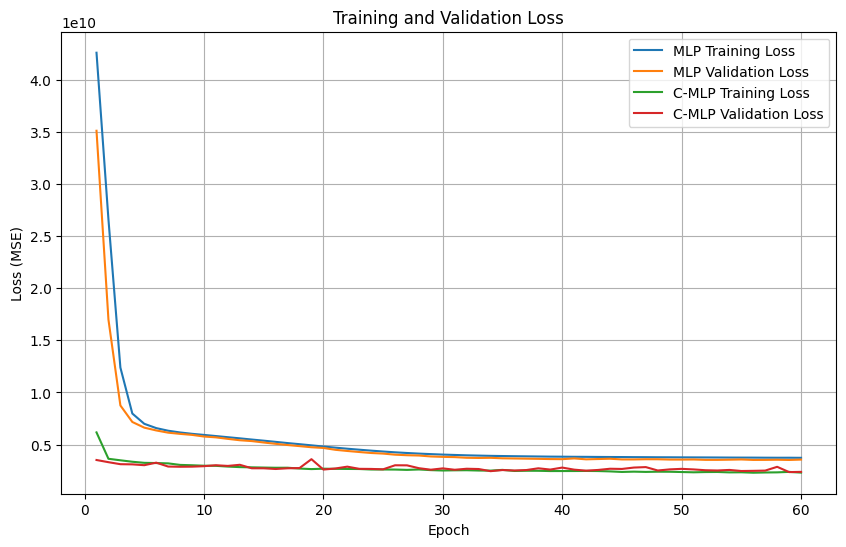

In [46]:
plt.figure(figsize=(10, 6))
plt.plot(range(1, hparams['epochs'] + 1), train_loss, label='MLP Training Loss')
plt.plot(range(1, hparams['epochs'] + 1), val_loss, label='MLP Validation Loss')
plt.plot(range(1, HyperParam['epochs'] + 1), C_train_loss, label='C-MLP Training Loss')
plt.plot(range(1, HyperParam['epochs'] + 1), C_val_loss, label='C-MLP Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.grid(True)
plt.show()

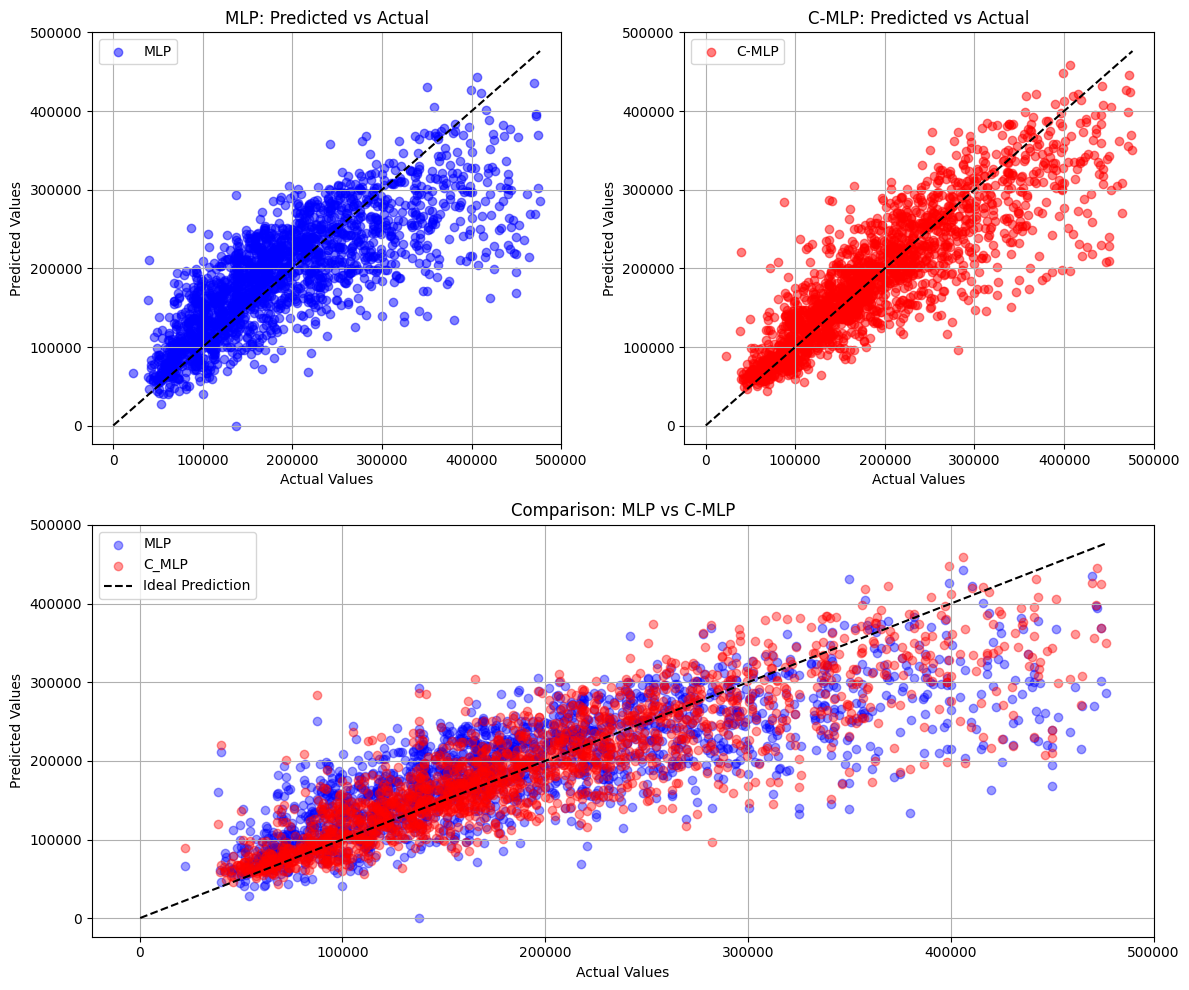

In [47]:
# Create a single figure to compare both models
plt.figure(figsize=(12, 10))

# Determine the overall min and max values for consistent axes
all_targets = np.concatenate([test_targets.numpy(), C_test_targets.numpy()])
all_predictions = np.concatenate([test_predictions.numpy(), C_test_predictions.numpy()])
min_val = min(all_targets.min(), all_predictions.min())
max_val = max(all_targets.max(), all_predictions.max())

# Plot the simple model predictions
plt.subplot(2, 2, 1)
plt.scatter(test_targets.numpy(), test_predictions.numpy(), alpha=0.5, color='blue', label='MLP')
plt.plot([min_val, max_val], [min_val, max_val], 'k--')
plt.title('MLP: Predicted vs Actual')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.grid(True)
plt.legend()

# Plot the complex model predictions
plt.subplot(2, 2, 2)
plt.scatter(C_test_targets.numpy(), C_test_predictions.numpy(), alpha=0.5, color='red', label='C-MLP')
plt.plot([min_val, max_val], [min_val, max_val], 'k--')
plt.title('C-MLP: Predicted vs Actual')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.grid(True)
plt.legend()

# Plot both models together for direct comparison
plt.subplot(2, 1, 2)
plt.scatter(test_targets.numpy(), test_predictions.numpy(), alpha=0.4, color='blue', label='MLP')
plt.scatter(C_test_targets.numpy(), C_test_predictions.numpy(), alpha=0.4, color='red', label='C_MLP')
plt.plot([min_val, max_val], [min_val, max_val], 'k--', label='Ideal Prediction')
plt.title('Comparison: MLP vs C-MLP')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

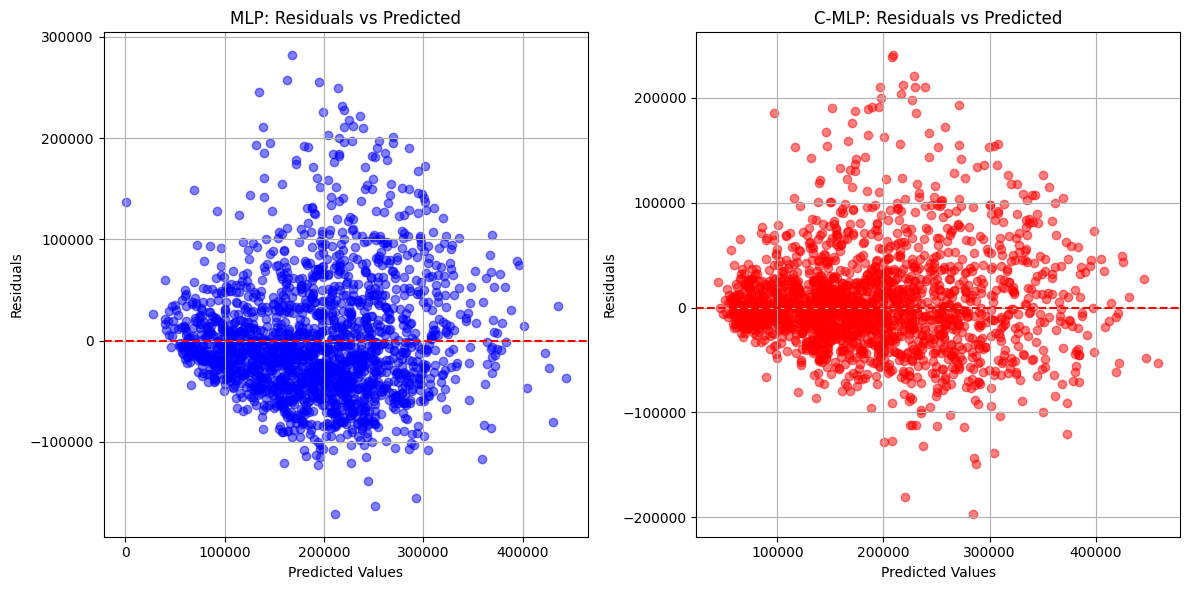

In [49]:
# Additional visualization: Residual plots
plt.figure(figsize=(12, 6))

# Calculate residuals
simple_residuals = test_targets.numpy() - test_predictions.numpy()
complex_residuals = C_test_targets.numpy() - C_test_predictions.numpy()

# Plot residuals for mlp
plt.subplot(1, 2, 1)
plt.scatter(test_predictions.numpy(), simple_residuals, alpha=0.5, color='blue')
plt.axhline(y=0, color='r', linestyle='--')
plt.title('MLP: Residuals vs Predicted')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.grid(True)

# Plot residuals for c-mlp
plt.subplot(1, 2, 2)
plt.scatter(C_test_predictions.numpy(), complex_residuals, alpha=0.5, color='red')
plt.axhline(y=0, color='r', linestyle='--')
plt.title('C-MLP: Residuals vs Predicted')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.grid(True)

plt.tight_layout()
plt.show()

In [50]:
print(f"Test MSE for MLP:   {test_mse:.4f}")
print(f"Test MSE for C-MLP: {C_test_mse:.4f}")

print(f"\nTest RMSE for MLP:   {test_rmse:.4f}")
print(f"Test RMSE for C-MLP: {C_test_rmse:.4f}")

print(f"\nTest MAE for MLP:   {test_mae:.4f}")
print(f"Test MAE for C-MLP: {C_test_mae:.4f}")

print(f"\nTest R² for MLP:   {test_r2:.4f}")
print(f"Test R² for C-MLP: {C_test_r2:.4f}")

Test MSE for MLP:   3493641472.0000
Test MSE for C-MLP: 2289352704.0000

Test RMSE for MLP:   59107.0352
Test RMSE for C-MLP: 47847.1797

Test MAE for MLP:   44065.1680
Test MAE for C-MLP: 32991.2773

Test R² for MLP:   0.6185
Test R² for C-MLP: 0.7500


In [51]:
print("Hyperparametes for MLP:   ",hparams)
print("Hyperparametes for C-MLP: ",HyperParam)

Hyperparametes for MLP:    {'batch_size': 64, 'lr': 0.1, 'epochs': 60}
Hyperparametes for C-MLP:  {'batch_size': 32, 'lr': 0.098, 'epochs': 60}
